# Reliability: Sensitivity to Small Input Noise

Tests whether the rating is stable under input perturbations too small to reflect
genuine differences in performance - the kind of off-by-one ambiguity that can
survive user validation (e.g. 22 vs 23 passes from a slightly unclear screenshot).
Two real performances differing only by this kind of noise should get the same -
or very nearly the same - rating.

Originally scoped alongside a half-length invariance test. That test turned out
to be untestable: zero variance in half_length across all 155 matches, and
separately untestable in principle given how the service uses it (a single
scalar multiplication, never referenced again downstream - any counterfactual
built to test it would pass by construction regardless of whether a bug exists
anywhere else in the pipeline). This notebook covers the noise-sensitivity
question only.

**Design (pre-registered before running):**
- ICC2 (two-way random effects, absolute agreement, single measure) -
  Shrout & Fleiss
- Targets = real outfield performances; raters = 1 original + 10 noisy variants
- Noise: ±7.5% on volume-type stats (passes, dribbles, tackles, possession_won,
  possession_lost, fouls_committed, offsides, distance_covered,
  distance_sprinted, shots), rounded to nearest integer. Goals, assists,
  percentages, and minutes_played untouched.
- Interpretation bands (Koo & Li, 2016): <0.5 poor, 0.5-0.75 moderate,
  0.75-0.9 good, >0.9 excellent - decided before seeing the result.

In [51]:
from pathlib import Path
import sys
import json
import pandas as pd
import numpy as np
import scipy.stats as stats
import pingouin as pg
import time
import matplotlib.pyplot as plt

# Define the project root
project_root = Path("..").resolve().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

matches_path = project_root / "tests" / "fixtures" / "full_example_data" / "data" / "valencia_cf_1" / "matches.json"

from src.services.analytics.match_ratings_service import MatchRatingsService

In [52]:
RANDOM_SEED = 42

# Noise perturbation design
NOISE_FRACTION = 0.075  # ± 7.5% of each stat's own value
N_NOISY_VARIANTS = 10   # plus the original = 11 raters per target
VOL_COLS_TO_PERTURB = [
    "passes", "dribbles", "tackles", "possession_won", "possession_lost",
    "fouls_committed", "offsides", "distance_covered", "distance_sprinted",
    "shots",
]

# Bootstrap - lower resample count than the 5000 used in the construct-validity
# notebook, since pingouin's ANOVA call is the bottleneck and gets re-run per
# resample. Worth timing one resample before committing to the full run.
N_BOOTSTRAP_RESAMPLES = 1000

# Interpretation bands for ICC, pre-registered before seeing results (Koo & Li 2016)
ICC_BANDS = {
    "poor":      (0.00, 0.50),
    "moderate":  (0.50, 0.75),
    "good":      (0.75, 0.90),
    "excellent": (0.90, 1.01),
}

def classify_icc(icc_value: float) -> str:
    return next(
        (
            label
            for label, (lo, hi) in ICC_BANDS.items()
            if lo <= icc_value < hi
        ),
        "excellent",
    )

In [53]:
with open(project_root / "config" / "performance_weights.json", "r") as f:
    weights = json.load(f)

with open(project_root / "config" / "performance_means_stds.json", "r") as f:
    means_stds = json.load(f)

real_service = MatchRatingsService(weights, means_stds)

## Generating Noisy Variants

For each real outfield performance, generate 10 perturbed copies: each stat in
`VOL_COLS_TO_PERTURB` nudged by a random factor within ±7.5% of its own value,
rounded to the nearest integer, floored at 0. Everything else - goals, assists,
percentages, minutes_played, positions_played - copied through unchanged, since
those aren't the kind of stat a validator would plausibly misjudge by a small
amount.

In [54]:
with open(matches_path, "r") as f:
    data = json.load(f)

In [55]:
DECIMAL_NOISE_COLS = {"distance_covered", "distance_sprinted"}

def generate_noisy_variant(performance: dict, cols_to_perturb: list[str] = None,
                            magnitude: int = 1, rng_override: np.random.Generator = None,
                            decimal_cols: set[str] = DECIMAL_NOISE_COLS) -> dict:
    """Generalised version of the original ±1 noise generator. Called with no
    arguments beyond `performance`, this reproduces the exact original behaviour
    (VOL_COLS_TO_PERTURB, magnitude 1, the module-level rng from Section 2) -
    the sweep and GK sections override cols_to_perturb/magnitude/rng_override
    explicitly."""
    if cols_to_perturb is None:
        cols_to_perturb = VOL_COLS_TO_PERTURB
    active_rng = rng_override if rng_override is not None else rng  # falls back to the Section 2 generator

    variant = performance.copy()
    for col in cols_to_perturb:
        if col not in variant or not isinstance(variant[col], (int, float)):
            continue
        if col in decimal_cols:
            offset = active_rng.choice(np.arange(-magnitude, magnitude + 1) * 0.1)
            variant[col] = round(max(0.0, variant[col] + offset), 1)
        else:
            offset = active_rng.integers(-magnitude, magnitude + 1)
            variant[col] = max(0, int(variant[col] + offset))
    return variant

In [56]:
# Grab one real outfield performance to eyeball the perturbation behaviour
example_match = data[0]
example_perf = next(p for p in example_match['player_performances'] if p['performance_type'] == 'Outfield')

print("Original:", {k: example_perf[k] for k in VOL_COLS_TO_PERTURB if k in example_perf})
for i in range(3):
    variant = generate_noisy_variant(example_perf)
    print(f"Variant {i+1}:", {k: variant[k] for k in VOL_COLS_TO_PERTURB if k in variant})

Original: {'passes': 16, 'dribbles': 11, 'tackles': 2, 'possession_won': 3, 'possession_lost': 1, 'fouls_committed': 0, 'offsides': 0, 'distance_covered': 8.8, 'distance_sprinted': 4.8, 'shots': 0}
Variant 1: {'passes': 15, 'dribbles': 10, 'tackles': 1, 'possession_won': 2, 'possession_lost': 2, 'fouls_committed': 0, 'offsides': 0, 'distance_covered': np.float64(8.8), 'distance_sprinted': np.float64(4.8), 'shots': 0}
Variant 2: {'passes': 16, 'dribbles': 11, 'tackles': 2, 'possession_won': 2, 'possession_lost': 1, 'fouls_committed': 1, 'offsides': 0, 'distance_covered': np.float64(8.8), 'distance_sprinted': np.float64(4.8), 'shots': 0}
Variant 3: {'passes': 16, 'dribbles': 11, 'tackles': 2, 'possession_won': 2, 'possession_lost': 1, 'fouls_committed': 1, 'offsides': 0, 'distance_covered': np.float64(8.8), 'distance_sprinted': np.float64(4.8), 'shots': 1}


## Running All Raters Through the Service

For each real outfield performance: rater 0 is the unperturbed original, raters
1-10 are independently generated noisy variants. All run through the same real,
unmodified `MatchRatingsService` - nothing's being disabled here, only inputs are
varying.

In [57]:
records = []

for match in data:
    match_overview = match['data']
    half_length = match_overview['half_length']

    for perf in match['player_performances']:
        if perf['performance_type'] != 'Outfield':
            continue

        target_id = f"{match['id']}_{perf['player_id']}"

        # Rater 0: the original, unperturbed performance
        rating = real_service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
        records.append({'target': target_id, 'rater': 0, 'rating': rating})

        # Raters 1-10: independently generated noisy variants
        for rater_id in range(1, N_NOISY_VARIANTS + 1):
            variant = generate_noisy_variant(perf)
            rating = real_service.calculate_outfield_rating(variant, match_overview, half_length, "Valencia CF")
            records.append({'target': target_id, 'rater': rater_id, 'rating': rating})

icc_df = pd.DataFrame(records)
icc_df['rating'] = icc_df['rating'].astype(float)  # drops any lingering numpy scalar typing

print(f"Targets: {icc_df['target'].nunique()}")
print(f"Rows (targets x raters): {len(icc_df)}")

Targets: 2246
Rows (targets x raters): 24706


In [58]:
n_before = len(icc_df)
icc_df = icc_df.dropna(subset=['rating'])
n_after = len(icc_df)
print(f"Dropped {n_before - n_after} rows with missing rating ({n_before} -> {n_after})")

# A target needs all 11 raters present to contribute to ICC - a target where only
# some variants returned None (rather than all 11) would corrupt the variance
# decomposition rather than just shrinking the sample, since pingouin expects a
# balanced design.
rater_counts = icc_df.groupby('target')['rater'].count()
incomplete_targets = rater_counts[rater_counts < N_NOISY_VARIANTS + 1].index
if len(incomplete_targets) > 0:
    print(f"Dropping {len(incomplete_targets)} targets with incomplete rater sets")
    icc_df = icc_df[~icc_df['target'].isin(incomplete_targets)]

Dropped 605 rows with missing rating (24706 -> 24101)


## Computing ICC2

Single random raters, absolute agreement - the design decided earlier. Raters here
are a genuine random sample from the space of plausible small perturbations (not
a small fixed set of specific conditions), and the question is whether the actual
rating value holds steady, not just whether relative ranking survives.

In [59]:
icc_results = pg.intraclass_corr(data=icc_df, targets='target', raters='rater', ratings='rating')
icc_results

,Type,ICC,F,df1,df2,pval,CI95
0,"ICC(1,1)",0.974510,421.550011,2190,21910,0.0,"[0.97, 0.98]"
1,"ICC(A,1)",0.974510,421.597333,2190,21900,0.0,"[0.97, 0.98]"
2,"ICC(C,1)",0.974513,421.597333,2190,21900,0.0,"[0.97, 0.98]"
3,"ICC(1,k)",0.997628,421.550011,2190,21910,0.0,"[1.0, 1.0]"
4,"ICC(A,k)",0.997628,421.597333,2190,21900,0.0,"[1.0, 1.0]"
5,"ICC(C,k)",0.997628,421.597333,2190,21900,0.0,"[1.0, 1.0]"


In [60]:
icc2_row = icc_results[icc_results['Type'] == 'ICC(A,1)'].iloc[0]
icc2_value = icc2_row['ICC']

print(f"ICC(A,1) = {icc2_value:.4f}")
print(f"Interpretation (Koo & Li bands): {classify_icc(icc2_value)}")

ICC(A,1) = 0.9745
Interpretation (Koo & Li bands): excellent


In [61]:
# Precompute each target's 11 rows once - resampling becomes dict lookups
# rather than re-filtering the full frame each time, same pattern as
# cluster_bootstrap_spearman's pre-split step in the other notebook.
target_groups = {tid: sub.reset_index(drop=True) for tid, sub in icc_df.groupby('target')}
all_target_ids = np.array(list(target_groups.keys()))
n_targets = len(all_target_ids)

def compute_icc2(df):
    results = pg.intraclass_corr(data=df, targets='target', raters='rater', ratings='rating')
    return results[results['Type'] == 'ICC(A,1)']['ICC'].iloc[0]

def bootstrap_icc2(n_resamples, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    boot_iccs = np.empty(n_resamples)
    for i in range(n_resamples):
        sampled_ids = rng.choice(all_target_ids, size=n_targets, replace=True)
        frames = []
        for new_id, original_id in enumerate(sampled_ids):
            sub = target_groups[original_id].copy()
            sub['target'] = new_id  # relabel - a target drawn twice must not be
                                     # merged into one 22-rater group
            frames.append(sub)
        boot_iccs[i] = compute_icc2(pd.concat(frames, ignore_index=True))
    return boot_iccs

In [62]:
start = time.time()
_ = bootstrap_icc2(n_resamples=5)
per_resample = (time.time() - start) / 5
print(f"~{per_resample:.2f}s per resample -> estimated {per_resample * N_BOOTSTRAP_RESAMPLES / 60:.1f} min for {N_BOOTSTRAP_RESAMPLES} resamples")

~9.30s per resample -> estimated 155.0 min for 1000 resamples


In [63]:
def icc_a1_closed_form(ratings_matrix: np.ndarray) -> float:
    """Closed-form ICC(A,1) - two-way random, absolute agreement, single measure -
    from a balanced (n_targets x n_raters) matrix via the classic ANOVA variance-
    component formula (Shrout & Fleiss ICC(2,1), identical to McGraw & Wong's
    ICC(A,1)). Same statistic pingouin reports, computed directly rather than via
    its general six-type ANOVA table - orders of magnitude faster per call.
    """
    n, k = ratings_matrix.shape
    grand_mean = ratings_matrix.mean()
    row_means = ratings_matrix.mean(axis=1)  # per target
    col_means = ratings_matrix.mean(axis=0)  # per rater

    ss_total = np.sum((ratings_matrix - grand_mean) ** 2)
    ss_rows = k * np.sum((row_means - grand_mean) ** 2)
    ss_cols = n * np.sum((col_means - grand_mean) ** 2)
    ss_error = ss_total - ss_rows - ss_cols

    ms_rows = ss_rows / (n - 1)
    ms_cols = ss_cols / (k - 1)
    ms_error = ss_error / ((n - 1) * (k - 1))

    return (ms_rows - ms_error) / (
        ms_rows + (k - 1) * ms_error + (k / n) * (ms_cols - ms_error)
    )

In [64]:
ratings_wide = icc_df.pivot(index='target', columns='rater', values='rating').values
icc_check = icc_a1_closed_form(ratings_wide)
print(f"Closed-form ICC(A,1) = {icc_check:.4f} (pingouin reported {icc2_value:.4f})")

Closed-form ICC(A,1) = 0.9745 (pingouin reported 0.9745)


In [65]:
def bootstrap_icc_a1_fast(ratings_matrix: np.ndarray, n_resamples: int, seed=RANDOM_SEED) -> np.ndarray:
    rng = np.random.default_rng(seed)
    n = ratings_matrix.shape[0]
    boot_iccs = np.empty(n_resamples)
    for i in range(n_resamples):
        idx = rng.choice(n, size=n, replace=True)
        boot_iccs[i] = icc_a1_closed_form(ratings_matrix[idx])
    return boot_iccs

In [66]:
start = time.time()
boot_iccs = bootstrap_icc_a1_fast(ratings_wide, n_resamples=N_BOOTSTRAP_RESAMPLES)
print(f"{time.time()-start:.2f}s total for {N_BOOTSTRAP_RESAMPLES} resamples")

icc_ci_l, icc_ci_h = np.percentile(boot_iccs, [2.5, 97.5])
print(f"Bootstrap 95% CI: [{icc_ci_l:.4f}, {icc_ci_h:.4f}]")

0.27s total for 1000 resamples
Bootstrap 95% CI: [0.9723, 0.9765]


## Sensitivity to Noise Magnitude

A single fixed magnitude (±1 / ±0.1) only answers "is the rating robust at this
specific noise size" - it can't distinguish genuine robustness from having
happened to pick a magnitude too small to expose a problem. Sweeping magnitude
shows whether reliability degrades gracefully or falls off a cliff somewhere.

In [67]:
NOISE_MAGNITUDES = [1, 2, 3, 4, 5]  # distance fields scale as magnitude x 0.1

# Precompute the original (unperturbed) rating once per target - it never
# changes across magnitude levels, no need to recompute it 5 times.
performance_lookup = {}
original_ratings = {}

for match in data:
    match_overview = match['data']
    half_length = match_overview['half_length']
    for perf in match['player_performances']:
        if perf['performance_type'] != 'Outfield':
            continue
        target_id = f"{match['id']}_{perf['player_id']}"
        performance_lookup[target_id] = (perf, match_overview, half_length)
        original_ratings[target_id] = real_service.calculate_outfield_rating(
            perf, match_overview, half_length, "Valencia CF"
        )

# Same minutes_played<10 gate as before - invariant across noise magnitude, so
# safe to resolve once up front.
valid_targets = [tid for tid, r in original_ratings.items() if r is not None]
print(f"Valid targets: {len(valid_targets)} (dropped {len(original_ratings) - len(valid_targets)} low-minute performances)")

Valid targets: 2191 (dropped 55 low-minute performances)


In [68]:
def run_sweep_level(magnitude: int, seed: int = RANDOM_SEED) -> np.ndarray:
    rng_local = np.random.default_rng(seed)
    matrix = np.empty((len(valid_targets), N_NOISY_VARIANTS + 1))
    for i, tid in enumerate(valid_targets):
        perf, match_overview, half_length = performance_lookup[tid]
        matrix[i, 0] = original_ratings[tid]
        for r in range(1, N_NOISY_VARIANTS + 1):
            variant = generate_noisy_variant(perf, VOL_COLS_TO_PERTURB, magnitude, rng_local)
            matrix[i, r] = real_service.calculate_outfield_rating(variant, match_overview, half_length, "Valencia CF")
    return matrix

sweep_results = []
for magnitude in NOISE_MAGNITUDES:
    matrix = run_sweep_level(magnitude)
    icc_value = icc_a1_closed_form(matrix)
    boot_iccs = bootstrap_icc_a1_fast(matrix, n_resamples=N_BOOTSTRAP_RESAMPLES)
    ci_l, ci_h = np.percentile(boot_iccs, [2.5, 97.5])
    sweep_results.append({'magnitude': magnitude, 'icc': icc_value, 'ci_low': ci_l, 'ci_high': ci_h})
    print(f"Magnitude ±{magnitude}: ICC(A,1) = {icc_value:.4f}  CI [{ci_l:.4f}, {ci_h:.4f}]")

sweep_df = pd.DataFrame(sweep_results)

Magnitude ±1: ICC(A,1) = 0.9747  CI [0.9725, 0.9766]
Magnitude ±2: ICC(A,1) = 0.9458  CI [0.9416, 0.9498]
Magnitude ±3: ICC(A,1) = 0.9154  CI [0.9086, 0.9214]
Magnitude ±4: ICC(A,1) = 0.8859  CI [0.8772, 0.8937]
Magnitude ±5: ICC(A,1) = 0.8562  CI [0.8456, 0.8660]


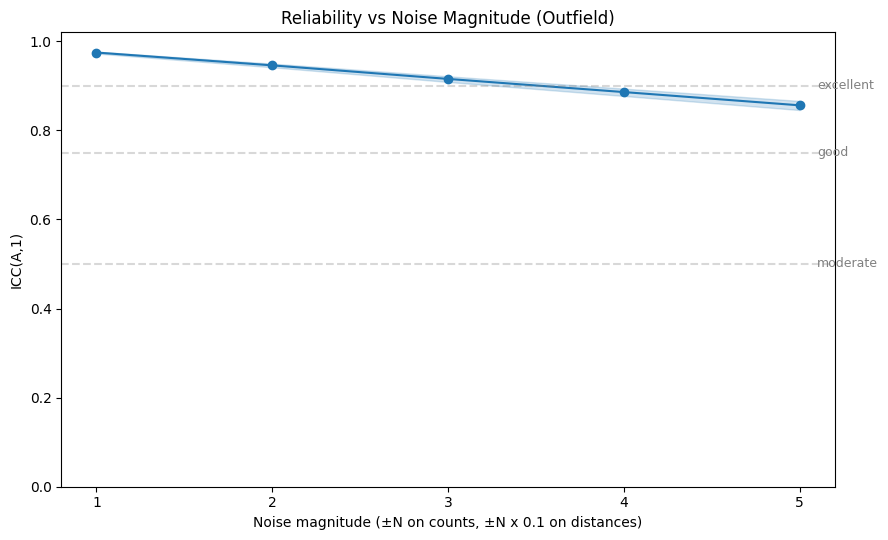

In [69]:
plt.figure(figsize=(9, 5.5))
plt.plot(sweep_df['magnitude'], sweep_df['icc'], marker='o', color='#1f77b4')
plt.fill_between(sweep_df['magnitude'], sweep_df['ci_low'], sweep_df['ci_high'], alpha=0.2, color='#1f77b4')

for threshold, label in [(0.9, 'excellent'), (0.75, 'good'), (0.5, 'moderate')]:
    plt.axhline(threshold, linestyle='--', alpha=0.3, color='gray')
    plt.text(NOISE_MAGNITUDES[-1] + 0.1, threshold, label, fontsize=9, va='center', color='gray')

plt.xlabel("Noise magnitude (±N on counts, ±N x 0.1 on distances)")
plt.ylabel("ICC(A,1)")
plt.title("Reliability vs Noise Magnitude (Outfield)")
plt.xticks(NOISE_MAGNITUDES)
plt.ylim(0, 1.02)
plt.tight_layout()
plt.show()

## GK Reliability

Outfield-only so far. GK ratings use a different vol_cols list (shots_against,
shots_on_target, saves, goals_conceded) and a different formula entirely.
Checked the source directly: `calculate_gk_rating` has no low-minutes None gate
- the only such gate in the file is outfield-specific - so no filtering step is
needed here. Much smaller n (~155, roughly one GK performance per match)
than the outfield set, which will show up as wider bootstrap CIs.

In [70]:
GK_VOL_COLS_TO_PERTURB = ["shots_against", "shots_on_target", "saves", "goals_conceded"]

gk_performance_lookup = {}
gk_original_ratings = {}

for match in data:
    match_overview = match['data']
    half_length = match_overview['half_length']
    for perf in match['player_performances']:
        if perf['performance_type'] != 'GK':
            continue
        target_id = f"{match['id']}_{perf['player_id']}"
        gk_performance_lookup[target_id] = (perf, match_overview, half_length)
        gk_original_ratings[target_id] = real_service.calculate_gk_rating(
            perf, match_overview, half_length, "Valencia CF"
        )

gk_valid_targets = [tid for tid, r in gk_original_ratings.items() if r is not None]
print(f"GK targets: {len(gk_valid_targets)} (None returned for {len(gk_original_ratings) - len(gk_valid_targets)})")

GK targets: 155 (None returned for 0)


In [71]:
def run_gk_sweep_level(magnitude: int, seed: int = RANDOM_SEED) -> np.ndarray:
    rng_local = np.random.default_rng(seed)
    matrix = np.empty((len(gk_valid_targets), N_NOISY_VARIANTS + 1))
    for i, tid in enumerate(gk_valid_targets):
        perf, match_overview, half_length = gk_performance_lookup[tid]
        matrix[i, 0] = gk_original_ratings[tid]
        for r in range(1, N_NOISY_VARIANTS + 1):
            variant = generate_noisy_variant(perf, GK_VOL_COLS_TO_PERTURB, magnitude, rng_local)
            matrix[i, r] = real_service.calculate_gk_rating(variant, match_overview, half_length, "Valencia CF")
    return matrix

gk_sweep_results = []
for magnitude in NOISE_MAGNITUDES:
    matrix = run_gk_sweep_level(magnitude)
    icc_value = icc_a1_closed_form(matrix)
    boot_iccs = bootstrap_icc_a1_fast(matrix, n_resamples=N_BOOTSTRAP_RESAMPLES)
    ci_l, ci_h = np.percentile(boot_iccs, [2.5, 97.5])
    gk_sweep_results.append({'magnitude': magnitude, 'icc': icc_value, 'ci_low': ci_l, 'ci_high': ci_h})
    print(f"GK, magnitude ±{magnitude}: ICC(A,1) = {icc_value:.4f}  CI [{ci_l:.4f}, {ci_h:.4f}]")

gk_sweep_df = pd.DataFrame(gk_sweep_results)

GK, magnitude ±1: ICC(A,1) = 0.5906  CI [0.5081, 0.6588]
GK, magnitude ±2: ICC(A,1) = 0.3758  CI [0.2907, 0.4511]
GK, magnitude ±3: ICC(A,1) = 0.2790  CI [0.2070, 0.3478]
GK, magnitude ±4: ICC(A,1) = 0.2155  CI [0.1588, 0.2704]
GK, magnitude ±5: ICC(A,1) = 0.1809  CI [0.1307, 0.2293]


In [72]:
print("Outfield vol_cols - mean (std):")
for col in VOL_COLS_TO_PERTURB:
    vals = [perf[col] for perf, _, _ in performance_lookup.values() if col in perf and isinstance(perf[col], (int, float))]
    print(f"  {col}: {np.mean(vals):.2f} ({np.std(vals):.2f})")

print("\nGK vol_cols - mean (std):")
for col in GK_VOL_COLS_TO_PERTURB:
    vals = [perf[col] for perf, _, _ in gk_performance_lookup.values() if col in perf and isinstance(perf[col], (int, float))]
    print(f"  {col}: {np.mean(vals):.2f} ({np.std(vals):.2f})")

outfield_ratings = np.array([original_ratings[t] for t in valid_targets])
gk_ratings = np.array([gk_original_ratings[t] for t in gk_valid_targets])
print(f"\nOutfield original ratings: mean={outfield_ratings.mean():.3f}, std={outfield_ratings.std():.3f}")
print(f"GK original ratings:       mean={gk_ratings.mean():.3f}, std={gk_ratings.std():.3f}")

Outfield vol_cols - mean (std):
  passes: 16.55 (12.60)
  dribbles: 13.85 (10.91)
  tackles: 3.59 (3.40)
  possession_won: 2.35 (2.58)
  possession_lost: 2.59 (2.49)
  fouls_committed: 0.15 (0.54)
  offsides: 0.06 (0.26)
  distance_covered: 7.80 (3.87)
  distance_sprinted: 2.72 (1.81)
  shots: 0.93 (1.61)

GK vol_cols - mean (std):
  shots_against: 6.51 (3.31)
  shots_on_target: 3.88 (2.47)
  saves: 3.14 (2.05)
  goals_conceded: 0.64 (0.93)

Outfield original ratings: mean=6.616, std=1.077
GK original ratings:       mean=6.512, std=1.281


In [73]:
def run_gk_single_stat_sweep(stat_to_perturb: str, magnitude: int, seed: int = RANDOM_SEED) -> np.ndarray:
    rng_local = np.random.default_rng(seed)
    matrix = np.empty((len(gk_valid_targets), N_NOISY_VARIANTS + 1))
    for i, tid in enumerate(gk_valid_targets):
        perf, match_overview, half_length = gk_performance_lookup[tid]
        matrix[i, 0] = gk_original_ratings[tid]
        for r in range(1, N_NOISY_VARIANTS + 1):
            variant = generate_noisy_variant(perf, [stat_to_perturb], magnitude, rng_local)
            matrix[i, r] = real_service.calculate_gk_rating(variant, match_overview, half_length, "Valencia CF")
    return matrix

single_stat_results = []
for stat in GK_VOL_COLS_TO_PERTURB:
    matrix = run_gk_single_stat_sweep(stat, magnitude=2)  # magnitude=2 - clearer
                                                            # separation than ±1
                                                            # without going all
                                                            # the way to the
                                                            # noisiest end
    icc_value = icc_a1_closed_form(matrix)
    single_stat_results.append({'stat': stat, 'icc': icc_value})
    print(f"{stat}: ICC(A,1) = {icc_value:.4f} (perturbing this stat alone, magnitude ±2)")

shots_against: ICC(A,1) = 0.9869 (perturbing this stat alone, magnitude ±2)
shots_on_target: ICC(A,1) = 1.0000 (perturbing this stat alone, magnitude ±2)
saves: ICC(A,1) = 0.9555 (perturbing this stat alone, magnitude ±2)
goals_conceded: ICC(A,1) = 0.3879 (perturbing this stat alone, magnitude ±2)


In [75]:
GK_REALISTIC_NOISE_COLS = ["shots_against", "shots_on_target", "saves"]

def run_gk_realistic_sweep_level(magnitude: int, seed: int = RANDOM_SEED) -> np.ndarray:
    rng_local = np.random.default_rng(seed)
    matrix = np.empty((len(gk_valid_targets), N_NOISY_VARIANTS + 1))
    for i, tid in enumerate(gk_valid_targets):
        perf, match_overview, half_length = gk_performance_lookup[tid]
        matrix[i, 0] = gk_original_ratings[tid]
        for r in range(1, N_NOISY_VARIANTS + 1):
            variant = generate_noisy_variant(perf, GK_REALISTIC_NOISE_COLS, magnitude, rng_local)
            matrix[i, r] = real_service.calculate_gk_rating(variant, match_overview, half_length, "Valencia CF")
    return matrix

corrected_gk_results = []
for magnitude in NOISE_MAGNITUDES:
    matrix = run_gk_realistic_sweep_level(magnitude)
    icc_value = icc_a1_closed_form(matrix)
    boot_iccs = bootstrap_icc_a1_fast(matrix, n_resamples=N_BOOTSTRAP_RESAMPLES)
    ci_l, ci_h = np.percentile(boot_iccs, [2.5, 97.5])
    corrected_gk_results.append({'magnitude': magnitude, 'icc': icc_value, 'ci_low': ci_l, 'ci_high': ci_h})
    print(f"GK (realistic inputs only), magnitude ±{magnitude}: ICC(A,1) = {icc_value:.4f}  CI [{ci_l:.4f}, {ci_h:.4f}]")

corrected_gk_df = pd.DataFrame(corrected_gk_results)

GK (realistic inputs only), magnitude ±1: ICC(A,1) = 0.9800  CI [0.9726, 0.9854]
GK (realistic inputs only), magnitude ±2: ICC(A,1) = 0.9440  CI [0.9248, 0.9579]
GK (realistic inputs only), magnitude ±3: ICC(A,1) = 0.9033  CI [0.8741, 0.9250]
GK (realistic inputs only), magnitude ±4: ICC(A,1) = 0.8724  CI [0.8352, 0.9006]
GK (realistic inputs only), magnitude ±5: ICC(A,1) = 0.8429  CI [0.7991, 0.8750]


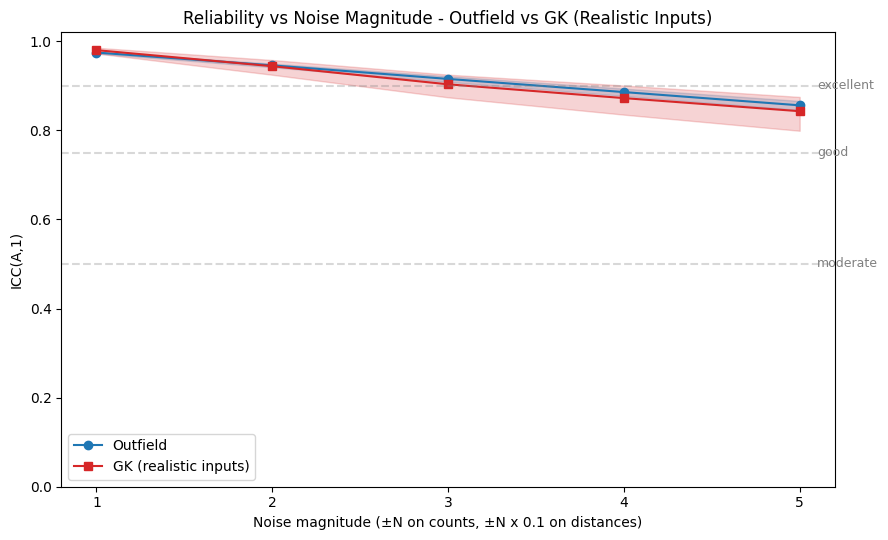

In [76]:
plt.figure(figsize=(9, 5.5))

plt.plot(sweep_df['magnitude'], sweep_df['icc'], marker='o', color='#1f77b4', label='Outfield')
plt.fill_between(sweep_df['magnitude'], sweep_df['ci_low'], sweep_df['ci_high'], alpha=0.2, color='#1f77b4')

plt.plot(corrected_gk_df['magnitude'], corrected_gk_df['icc'], marker='s', color='#d62728', label='GK (realistic inputs)')
plt.fill_between(corrected_gk_df['magnitude'], corrected_gk_df['ci_low'], corrected_gk_df['ci_high'], alpha=0.2, color='#d62728')

for threshold, label in [(0.9, 'excellent'), (0.75, 'good'), (0.5, 'moderate')]:
    plt.axhline(threshold, linestyle='--', alpha=0.3, color='gray')
    plt.text(NOISE_MAGNITUDES[-1] + 0.1, threshold, label, fontsize=9, va='center', color='gray')

plt.xlabel("Noise magnitude (±N on counts, ±N x 0.1 on distances)")
plt.ylabel("ICC(A,1)")
plt.title("Reliability vs Noise Magnitude - Outfield vs GK (Realistic Inputs)")
plt.xticks(NOISE_MAGNITUDES)
plt.ylim(0, 1.02)
plt.legend()
plt.tight_layout()
plt.show()